# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [ ]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential
from tensorflow import keras

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.2. Разделяем данные на обучающую и тестовую выборку

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

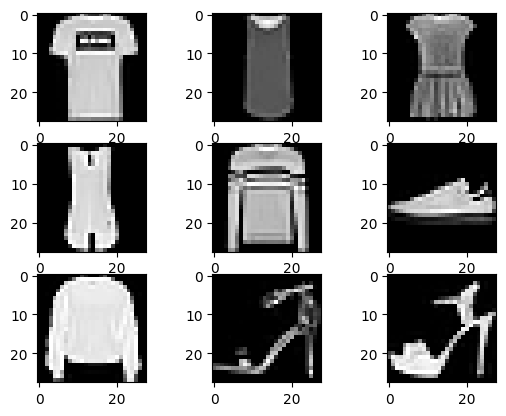

In [ ]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [ ]:
# нормализация входных данных
x_train = trainX / 255
x_test = testX / 255

y_train_cat = keras.utils.to_categorical(trainy, 10)
y_test_cat = keras.utils.to_categorical(testy, 10)

x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
# Ваш код
model = keras.Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10,  activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [ ]:
# Ваш код
EPOCH = 6

model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])


his = model.fit(trainX, y_train_cat, batch_size=32, epochs=EPOCH, validation_split=0.2)

model.evaluate(testX, y_test_cat) # метод evaluate() предназначен для оценки уже обученной модели с использованием данных проверки
                                   #(или тестирования) и соответствующих меток. Возвращает значение потерь и значения показателей для модели.

Epoch 1/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 43ms/step - accuracy: 0.8373 - loss: 0.7293 - val_accuracy: 0.8683 - val_loss: 0.3691
Epoch 2/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.8885 - loss: 0.3017 - val_accuracy: 0.8752 - val_loss: 0.3560
Epoch 3/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.9042 - loss: 0.2588 - val_accuracy: 0.9022 - val_loss: 0.2714
Epoch 4/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.9138 - loss: 0.2290 - val_accuracy: 0.8967 - val_loss: 0.2844
Epoch 5/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.9221 - loss: 0.2115 - val_accuracy: 0.9052 - val_loss: 0.2715
Epoch 6/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.9271 - loss: 0.1942 - val_accuracy: 0.9000 - val_loss: 0.2831
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8958 - loss: 0.3096


[0.30961135029792786, 0.895799994468689]

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

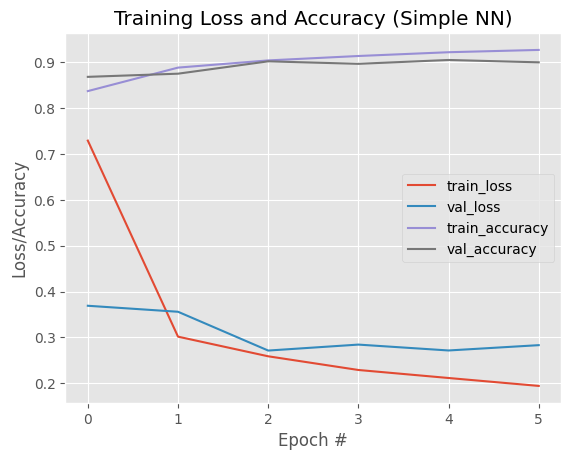

In [ ]:
# Ваш код
N = np.arange(0, EPOCH)
plt.style.use("ggplot")
plt.figure()
plt.plot(N, his.history["loss"], label="train_loss")
plt.plot(N, his.history["val_loss"], label="val_loss")
plt.plot(N, his.history["accuracy"], label="train_accuracy")
plt.plot(N, his.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy (Simple NN)")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



In [ ]:
def get_fashion_mnist_label(label):
    class_names = [
        "Футболка/топ",
        "Брюки",
        "Пуловер",
        "Платье",
        "Пальто",
        "Сандалии",
        "Рубашка",
        "Кроссовки",
        "Сумка",
        "Ботильоны"
    ]

    return class_names[label]

In [ ]:
# Ваш код
import cv2
from google.colab.patches import cv2_imshow

# Добавляем интерфейс для загрузки изображений напрямую из блокнота
from google.colab import files
def upload_image():
  uploaded = files.upload()

  # загружаем входное изображение, меняем его размер на необходимый и выводим его

  image = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE) # Преобразование изображения в оттенки серого при считывании
  image = cv2.resize(image, (28, 28)) # Изменение разрешения изображения
  image = cv2.bitwise_not(image) # Инверсия цветов (если в оригинале цифра написана черным цветом на белом фоне)
  orig = image
  image = image.reshape(-1, 28, 28, 1) # Приводим изображение из вида (28,28) в вид (1, 28, 28, 1)

  cv2_imshow(orig)
  return image

In [ ]:
# делаем предсказание на изображении
image=upload_image()
preds = model.predict(image)
print(preds)
i = preds.argmax(axis=1)[0]
print(get_fashion_mnist_label(i))

Saving рубашка.jpg to рубашка.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[5.1908079e-04 1.4598195e-04 1.1223224e-02 8.0591679e-05 3.8588583e-02
  2.6884550e-06 9.1154236e-01 9.2803006e-04 3.6896478e-02 7.3066993e-05]]
Рубашка


In [ ]:
# делаем предсказание на изображении
image=upload_image()
preds = model.predict(image)
print(preds)
i = preds.argmax(axis=1)[0]
print(get_fashion_mnist_label(i))

Saving пальто.jpg to пальто.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.15041313 0.00454766 0.23706533 0.21577941 0.19167095 0.0002838
  0.16834679 0.00089894 0.03067779 0.00031622]]
Пуловер


In [ ]:
# делаем предсказание на изображении
image=upload_image()
preds = model.predict(image)
print(preds)
i = preds.argmax(axis=1)[0]
print(get_fashion_mnist_label(i))

Saving платье.jpg to платье.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[7.0621376e-04 5.7055146e-05 7.2490738e-04 9.9279600e-01 4.0904181e-03
  4.0221718e-04 7.0918811e-04 2.1294116e-04 1.2006806e-04 1.8097054e-04]]
Платье


In [ ]:
# делаем предсказание на изображении
image=upload_image()
preds = model.predict(image)
print(preds)
i = preds.argmax(axis=1)[0]
print(get_fashion_mnist_label(i))

Saving футболка.jpg to футболка.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[7.9971635e-01 7.4097049e-13 1.5991800e-06 3.6865103e-07 6.1399142e-08
  2.1621283e-14 2.0028156e-01 1.8276881e-14 3.6636809e-12 2.0583917e-15]]
Футболка/топ


In [ ]:
# делаем предсказание на изображении
image=upload_image()
preds = model.predict(image)
print(preds)
i = preds.argmax(axis=1)[0]
print(get_fashion_mnist_label(i))

Saving кроссовки.jpg to кроссовки.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[6.8632977e-10 5.3103568e-14 8.1868635e-12 1.0056952e-13 1.4108300e-09
  6.2661917e-11 6.6298178e-10 8.6315644e-08 9.9999988e-01 3.3747607e-10]]
Сумка


# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from imutils import paths
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import pickle
import cv2
import os
from tqdm import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ваш код
# Скачиваем архив с набором данных
!curl -L -o indian_birds.zip \
  https://www.kaggle.com/api/v1/datasets/download/arjunbasandrai/25-indian-bird-species-with-226k-images

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9557M  100 9557M    0     0  80.8M      0  0:01:58  0:01:58 --:--:--  102M


In [ ]:
%%capture
# Распаковываем архив в папку dataset (%%capture подавляет вывод большого списка файлов)
!unzip indian_birds.zip -d dataset

In [ ]:
!rm -rf /content/dataset/training_data

In [ ]:
# Ваш код
import os
import shutil

base_path = "/content/dataset/training_set/training_set"

# Папки, которые нужно оставить
keep_folders = [
    "Asian Green Bee-Eater",
    "Brown-Headed Barbet",
    "Common Kingfisher"
]

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path) and folder not in keep_folders:
        shutil.rmtree(folder_path)
        print(f"Удалена папка: {folder}")

print("Готово")

Удалена папка: Indian Roller
Удалена папка: Common Myna
Удалена папка: Sarus Crane
Удалена папка: Northern Lapwing
Удалена папка: Common Rosefinch
Удалена папка: Red-Wattled Lapwing
Удалена папка: Indian Peacock
Удалена папка: Gray Wagtail
Удалена папка: Forest Wagtail
Удалена папка: Rufous Treepie
Удалена папка: Hoopoe
Удалена папка: Ruddy Shelduck
Удалена папка: Coppersmith Barbet
Удалена папка: White-Breasted Kingfisher
Удалена папка: House Crow
Удалена папка: Jungle Babbler
Удалена папка: White Wagtail
Удалена папка: White-Breasted Waterhen
Удалена папка: Common Tailorbird
Удалена папка: Indian Pitta
Удалена папка: Cattle Egret
Удалена папка: Indian Grey Hornbill
Готово ✅


In [ ]:
!rm -rf /content/dataset/training_set/training_set

In [ ]:
!cp -r "/content/dataset/training_set/Common Kingfisher" "/content/drive/MyDrive/ПР-3"

Классы: ['Asian Green Bee-Eater', 'Brown-Headed Barbet', 'Common Kingfisher']
Количество классов: 3

  📁 Asian Green Bee-Eater: 924 изображений
  📁 Brown-Headed Barbet: 924 изображений
  📁 Common Kingfisher: 924 изображений


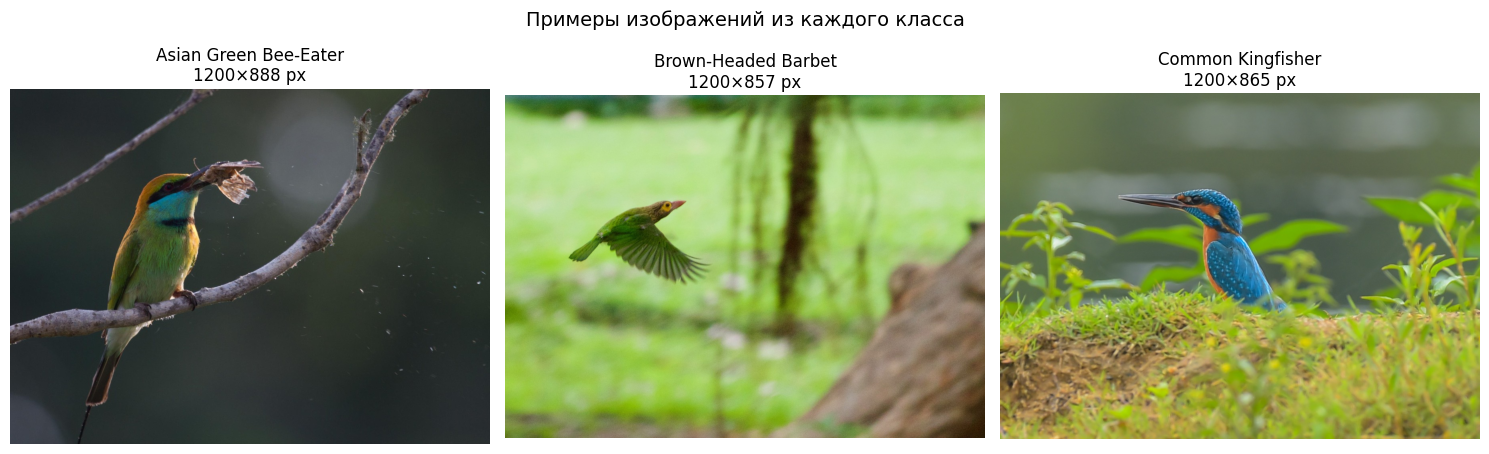

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/ПР-3'

classes = sorted(os.listdir(DATASET_PATH))
print(f"Классы: {classes}")
print(f"Количество классов: {len(classes)}\n")

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        print(f"  📁 {cls}: {len(os.listdir(cls_path))} изображений")

# Визуализация примеров
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    img = cv2.imread(os.path.join(cls_path, os.listdir(cls_path)[0]))
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'{cls}\n{img.shape[1]}×{img.shape[0]} px')
    axes[i].axis('off')

plt.suptitle('Примеры изображений из каждого класса', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = 128   # Размер изображения (64×64 пикселя)
CHANNELS = 3    # RGB

print(f"Входной тензор: {IMG_SIZE}×{IMG_SIZE}×{CHANNELS}")

Входной тензор: 128×128×3


In [ ]:
def load_images(imagePaths, img_size=64):
    data, labels = [], []

    for imagePath in tqdm(imagePaths, desc="Загрузка изображений", unit="img", colour="green"):
        try:
            image = cv2.imread(imagePath)
            # Изменяем размер, но НЕ разворачиваем в вектор — CNN работает с 2D-картой признаков
            image = cv2.resize(image, (img_size, img_size))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            data.append(image)
            labels.append(imagePath.split(os.path.sep)[-2])
        except:
            continue

    return data, labels


imagePaths = sorted(list(paths.list_images(DATASET_PATH)))
random.seed(42)
random.shuffle(imagePaths)

data, labels_str = load_images(imagePaths, IMG_SIZE)

# Нормализация пикселей в диапазон [0, 1]
data = np.array(data, dtype="float32") / 255.0
labels_str = np.array(labels_str)

print(f"Форма данных: {data.shape}  →  (изображений, высота, ширина, каналы)")
print(f"Классы: {np.unique(labels_str)}")

Загрузка изображений: 100%|██████████| 2772/2772 [11:27<00:00,  4.03img/s]


Форма данных: (2772, 128, 128, 3)  →  (изображений, высота, ширина, каналы)
Классы: ['Asian Green Bee-Eater' 'Brown-Headed Barbet' 'Common Kingfisher']


In [ ]:
lb = LabelBinarizer()
labels = lb.fit_transform(labels_str)

print(f"Классы: {lb.classes_}")
print(f"Форма меток: {labels.shape}")

for cls in lb.classes_:
    idx = np.where(labels_str == cls)[0][0]
    print(f"  '{cls}'  →  {labels[idx]}")

Классы: ['Asian Green Bee-Eater' 'Brown-Headed Barbet' 'Common Kingfisher']
Форма меток: (2772, 3)
  'Asian Green Bee-Eater'  →  [1 0 0]
  'Brown-Headed Barbet'  →  [0 1 0]
  'Common Kingfisher'  →  [0 0 1]


In [ ]:
trainX, testX, trainY, testY = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {trainX.shape}")
print(f"Тестовая выборка:  {testX.shape}")

Обучающая выборка: (2217, 128, 128, 3)
Тестовая выборка:  (555, 128, 128, 3)


## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [ ]:
num_classes = len(lb.classes_)

model = Sequential([
    # Блок 1: извлекаем базовые признаки (края, текстуры), 128x128 -> 64x64
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
    MaxPooling2D(pool_size=(2, 2)),

    # Блок 2: извлекаем более сложные признаки (геометрические формы), 64x64 -> 32x32
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Блок 3: углубляем анализ деталей объектов, 32x32 -> 16x16
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Блок 4: извлекаем высокоуровневые признаки, 16x16 -> 8x8
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Блок 5: финальное сжатие признаков перед классификацией, 8x8 -> 4x4
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Преобразование многомерных карт признаков в одномерный вектор (4*4*64 = 1024 элемента)
    Flatten(),

    # Полносвязные слои (Dense) для принятия решения на основе собранных признаков
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),

    # Выходной слой: выдает вероятности для каждого из классов
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,192,835 (4.55 MB)

 Trainable params: 1,192,835 (4.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)
callbacks_list = [early_stopping, checkpoint, reduce_lr]


In [ ]:
INIT_LR = 0.0001
EPOCHS = 1000
BATCH_SIZE = 1024

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=INIT_LR),
    metrics=["accuracy"]
)

In [ ]:
H = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list
)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.6389 - loss: 0.8531 
Epoch 1: val_accuracy did not improve from 0.59640
3/3 ━━━━━━━━━━━━━━━━━━━━ 145s 34s/step - accuracy: 0.6378 - loss: 0.8551 - val_accuracy: 0.5604 - val_loss: 0.8897 - learning_rate: 1.0000e-04
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.5963 - loss: 0.8484 
Epoch 2: val_accuracy improved from 0.59640 to 0.64144, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 120s 35s/step - accuracy: 0.6013 - loss: 0.8468 - val_accuracy: 0.6414 - val_loss: 0.8295 - learning_rate: 1.0000e-04
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.6440 - loss: 0.8317 
Epoch 3: val_accuracy did not improve from 0.64144
3/3 ━━━━━━━━━━━━━━━━━━━━ 117s 34s/step - accuracy: 0.6450 - loss: 0.8313 - val_accuracy: 0.6414 - val_loss: 0.8229 - learning_rate: 1.0000e-04
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.6463 - lo

## 2.3. Сохраните полученные модели

In [ ]:
# Ваш код
model = load_model("/content/best_model.keras")
print("Лучшая модель загружена из best_model.h5")

Лучшая модель загружена из best_model.h5


In [ ]:
preds = model.predict(testX, batch_size=32)

print("\n" + "="*50)
print("ОТЧЕТ ПО КЛАССИФИКАЦИИ")
print("="*50)
print(classification_report(
    testY.argmax(axis=1),
    preds.argmax(axis=1),
    target_names=lb.classes_
))

NameError: name 'testX' is not defined

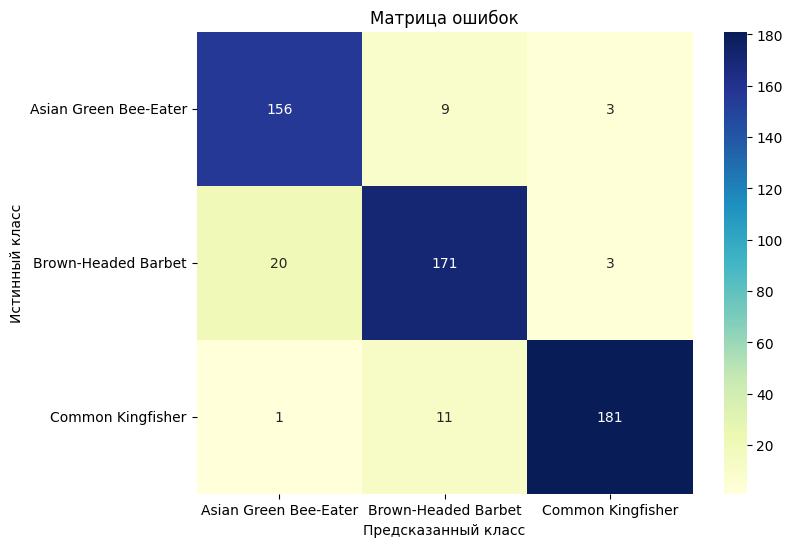

In [ ]:
conf_mat = confusion_matrix(testY.argmax(axis=1), preds.argmax(axis=1))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

## 2.4. Загрузите обученную модель из прошлой практической работы


In [ ]:
# Ваш код
classes = np.load("/content/classes.npy", allow_pickle=True)

# CNN
cnn_model = load_model("/content/best_model.keras")

# ИНС
ins_model = load_model("/content/birds.h5")

cnn_model.compile(loss='categorical_crossentropy', metrics=['accuracy'])
ins_model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

FileNotFoundError: [Errno 2] No such file or directory: '/content/classes.npy'


## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img
import numpy as np
import pandas as pd

print("CNN params:", cnn_model.count_params())
print("ИНС params:", ins_model.count_params())
print("Классы:", len(classes))

# Функция предобработки
def preprocess_image(img_path, size=128):
    img = load_img(img_path, target_size=(size, size))
    img_array = np.array(img) / 255.0
    cnn_input = np.expand_dims(img_array, 0)    # (1,128,128,3)
    ins_input = img_array.flatten().reshape(1, -1)  # (1,49152)
    return cnn_input, ins_input

# Загрузка изображений
uploaded = files.upload()
image_paths = list(uploaded.keys())[:15]

# Сравнение
results = []
for fname in image_paths:
    cnn_input, ins_input = preprocess_image(fname)

    cnn_pred = cnn_model.predict(cnn_input, verbose=0)
    ins_pred = ins_model.predict(ins_input, verbose=0)

    cnn_class = classes[np.argmax(cnn_pred)]
    cnn_conf = np.max(cnn_pred)
    ins_class = classes[np.argmax(ins_pred)]
    ins_conf = np.max(ins_pred)

    match = "+" if cnn_class == ins_class else "-"

    results.append([fname, cnn_class, f"{cnn_conf:.1%}", ins_class, f"{ins_conf:.1%}", match])
    print(f"{fname}: CNN={cnn_class}({cnn_conf:.1%}) ИНС={ins_class}({ins_conf:.1%}) {match}")

# Таблица статистики
df = pd.DataFrame(results, columns=['Файл', 'CNN', 'CNN_pred', 'ИНС', 'ИНС_pred', 'Совпадение'])
print("\nСРАВНЕНИЕ:")
print(df.to_markdown(index=False))

matches = df['Совпадение'].eq('+').sum()
total = len(df)
cnn_correct_rate = (df['CNN_pred'] > df['ИНС_pred']).mean()
print(f"\nСовпадений: {matches}/{total} ({matches/total:.0%})")

CNN params: 1192835
ИНС params: 50989571
Классы: 3


Saving Asian Green Bee-Eater.jpg to Asian Green Bee-Eater (1).jpg
Saving Asian Green Bee-Eater_1.jpg to Asian Green Bee-Eater_1 (1).jpg
Saving Asian Green Bee-Eater_2.jpg to Asian Green Bee-Eater_2 (1).jpg
Saving Asian Green Bee-Eater_3.jpg to Asian Green Bee-Eater_3 (1).jpg
Saving Asian Green Bee-Eater_4.jpg to Asian Green Bee-Eater_4 (1).jpg
Saving Brown-Headed Barbet .jpg to Brown-Headed Barbet  (1).jpg
Saving Brown-Headed Barbet_1.jpg to Brown-Headed Barbet_1 (1).jpg
Saving Brown-Headed Barbet_2.jpg to Brown-Headed Barbet_2 (1).jpg
Saving Brown-Headed Barbet_3.jpg to Brown-Headed Barbet_3 (1).jpg
Saving Brown-Headed Barbet_4.jpg to Brown-Headed Barbet_4 (1).jpg
Saving Common Kingfisher.jpg to Common Kingfisher (1).jpg
Saving Common Kingfisher_1.jpg to Common Kingfisher_1 (1).jpg
Saving Common Kingfisher_2.jpg to Common Kingfisher_2 (1).jpg
Saving Common Kingfisher_3.jpg to Common Kingfisher_3 (1).jpg
Saving Common Kingfisher_4.jpg to Common Kingfisher_4 (1).jpg
Asian Green Bee-Eate

Классы: ['Asian Green Bee-Eater' 'Brown-Headed Barbet' 'Common Kingfisher']


Saving Common Kingfisher_3.jpg to Common Kingfisher_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


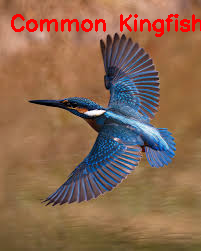


📊 Вероятности по классам:
  Asian Green Bee-Eater:   0.00%  
  Brown-Headed Barbet:   0.00%  
  Common Kingfisher: 100.00%  █████████████████████████████


In [ ]:
from google.colab import files
from google.colab.patches import cv2_imshow

# Загружаем пользовательское изображение
cnn_model = load_model("/content/best_model.keras")
lb = LabelBinarizer()
labels = lb.fit_transform(labels_str)  # Твои labels_str
print(f"Классы: {lb.classes_}")

class_names = lb.classes_

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Читаем изображение
image = cv2.imread(filename)
output = image.copy()

# Подготавливаем изображение: resize → flatten → normalize
image_processed = cv2.resize(image, (IMG_SIZE, IMG_SIZE)).flatten().astype("float") / 255.0

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_processed = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
image_processed = np.expand_dims(image_processed, axis=0)  # (1,H,W,C)
image_processed = image_processed.astype("float32") / 255.0

# Получаем предсказание
preds = cnn_model.predict(image_processed)
i = preds.argmax(axis=1)[0]

# Отображаем результат
label = class_names[i]
confidence = preds[0][i] * 100
text = f"{label}: {confidence:.2f}%"

cv2.putText(output, text, (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
cv2_imshow(output)

# Выводим вероятности для всех классов
print(f"\n📊 Вероятности по классам:")
for cls, prob in zip(class_names, preds[0]):
    bar = '█' * int(prob * 30)
    print(f"  {cls:>8s}: {prob*100:6.2f}%  {bar}")

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [1]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [2]:
# Ваш код здесь
train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

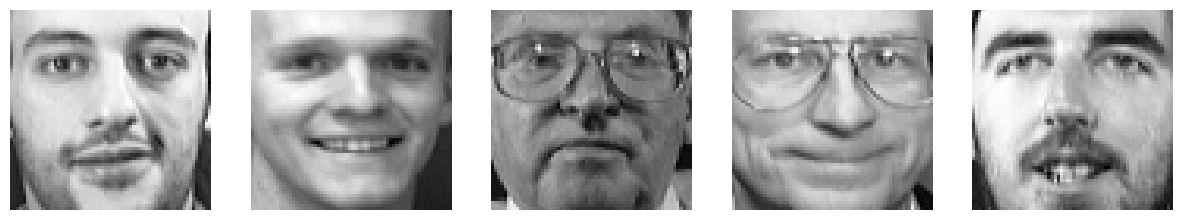

In [3]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [4]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [ ]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

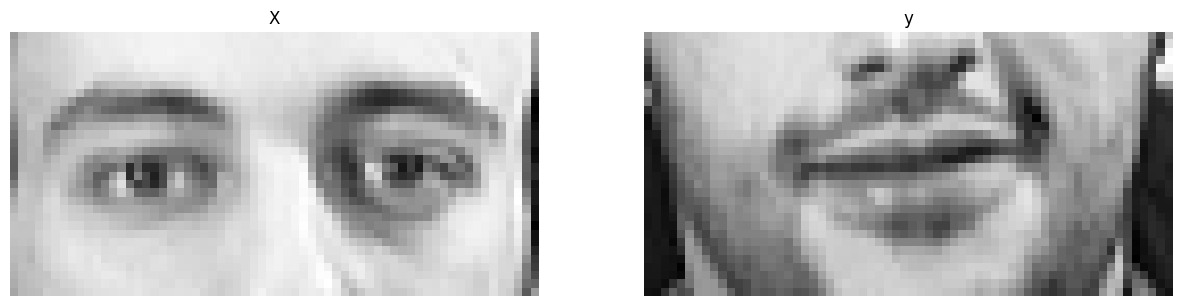

In [5]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [6]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [7]:
# Ваш код здесь
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Encoder
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 64, 1)),
    MaxPooling2D((2, 2)),  # (16, 32, 32)

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # (8, 16, 64)

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # (4, 8, 128)

    # Переход к полносвязным слоям
    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.3),  # чтобы уменьшить переобучение

    Dense(512, activation='relu'),

    # Выход (нижняя половина лица = 32*64 = 2048)
    Dense(2048, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [8]:
# Ваш код здесь
# Компиляция для восстановления изображения
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2048)           │     1,050,624 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,323,712 (8.86 MB)

 Trainable params: 2,323,712 (8.86 MB)

 Non-trainable params: 0 (0.00 B)

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [10]:
# Нормализация
X_train_cnn = X_train[..., None]
X_test_cnn = X_test[..., None]

In [11]:
# Ваш код здесь
EPOCHS = 50

H = model.fit(
    X_train_cnn, y_train_n,
    epochs=EPOCHS,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 0.0234 - mae: 0.1239 - val_loss: 0.0221 - val_mae: 0.1201
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0208 - mae: 0.1165 - val_loss: 0.0214 - val_mae: 0.1191
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0203 - mae: 0.1152 - val_loss: 0.0215 - val_mae: 0.1186
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0204 - mae: 0.1151 - val_loss: 0.0214 - val_mae: 0.1184
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0202 - mae: 0.1145 - val_loss: 0.0212 - val_mae: 0.1189
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0200 - mae: 0.1140 - val_loss: 0.0208 - val_mae: 0.1172
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0192 - mae: 0.1112 - val_loss: 0.0190 - val_mae: 0.1113
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0186 - mae: 0.1090 - val_loss: 0.0174 - val_mae: 0.1057
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0172 - mae

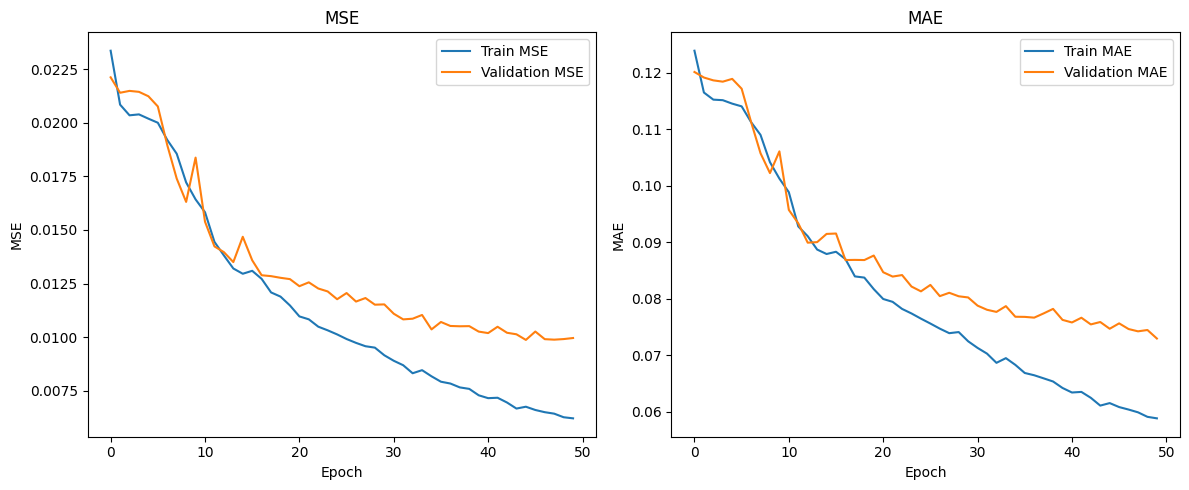

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# График MSE (loss)
plt.subplot(1,2,1)
plt.plot(H.history['loss'], label='Train MSE')
plt.plot(H.history['val_loss'], label='Validation MSE')
plt.title('MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# График MAE
plt.subplot(1,2,2)
plt.plot(H.history['mae'], label='Train MAE')
plt.plot(H.history['val_mae'], label='Validation MAE')
plt.title('MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

## 3.5. Сделайте предсказания на тестовых данных

In [13]:
# Ваш код здесь
y_pred = model.predict(X_test_cnn)
print(y_pred.shape)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 399ms/step
(80, 2048)


## 3.6. Посчитайте метрику качества на тестовых данных

In [15]:
# Ваш код здесь
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test_n, y_pred)
mae = mean_absolute_error(y_test_n, y_pred)

print("MSE:", mse)
print("MAE:", mae)

MSE: 0.009359657764434814
MAE: 0.07099884003400803


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [16]:
# Ваш код здесь
y_pred_img = y_pred.reshape(-1, 32, 64)
print(y_pred_img.shape)

(80, 32, 64)


Отрисуйте все предсказания.

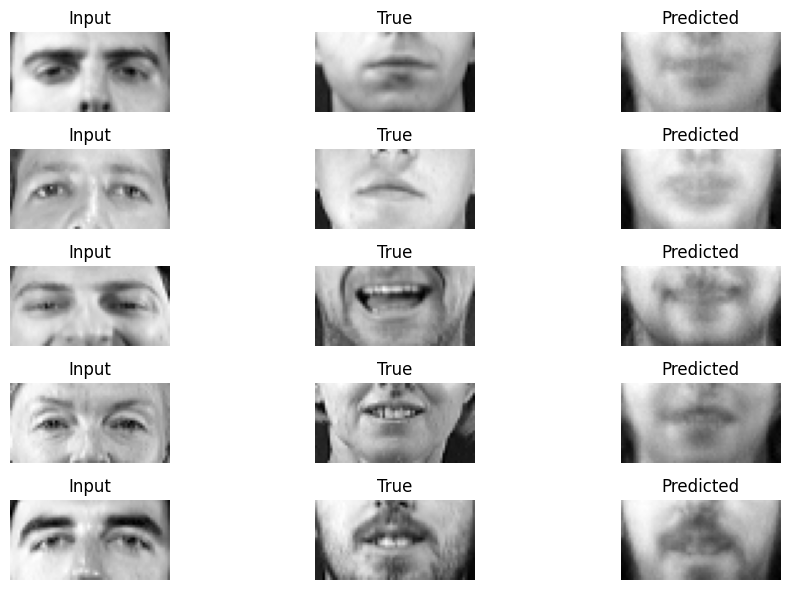

In [18]:
# Ваш код здесь
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(10, 6))

for i in range(n):
    # Верхняя часть
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title('Input')
    plt.axis('off')

    # Настоящий низ
    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(y_test[i], cmap='gray')
    plt.title('True')
    plt.axis('off')

    # Предсказанный низ
    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(y_pred_img[i], cmap='gray')
    plt.title('Predicted')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

Saving images_crop.jpg to images_crop.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


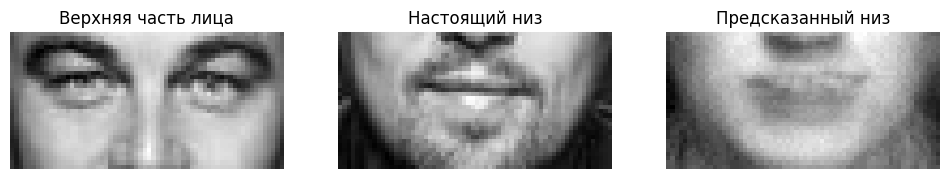

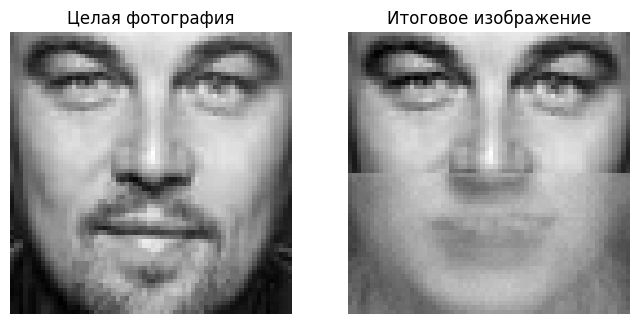

In [22]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(filename)

# Проверка
if img is None:
    raise ValueError("Ошибка загрузки изображения")

# Перевод в grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Resize до 64x64
img = cv2.resize(img, (64, 64))

# Нормализация
img = img / 255.0

# делим фотографию
upper = img[:32, :]
lower_true = img[32:, :]

# Подготовка
upper_input = upper.reshape(1, 32, 64, 1)

# Предсказание
lower_pred = model.predict(upper_input)
lower_pred = lower_pred.reshape(32, 64)

plt.figure(figsize=(12,4))

# Верх лица
plt.subplot(1, 3, 1)
plt.imshow(upper, cmap='gray')
plt.title('Верхняя часть лица')
plt.axis('off')

# Настоящий низ
plt.subplot(1, 3, 2)
plt.imshow(lower_true, cmap='gray')
plt.title('Настоящий низ')
plt.axis('off')

# Предсказанный низ
plt.subplot(1, 3, 3)
plt.imshow(lower_pred, cmap='gray')
plt.title('Предсказанный низ')
plt.axis('off')

plt.show()

full_pred = np.vstack((upper, lower_pred))
full_true = np.vstack((upper, lower_true))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(full_true, cmap='gray')
plt.title('Целая фотография')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(full_pred, cmap='gray')
plt.title('Итоговое изображение')
plt.axis('off')

plt.show()